# cace versus sea on the water interface

Two model families were trained on the same 500-frame water-interface slab, and this notebook reads all eight runs back.

The **cace** arms are cace's own published `fit-cace-nnp.py`.
The **sea** arms are the same cace training loop with DeepMD's `DescrptSeA` substituted at the input seam, built by `desc_bridging/deepmd_cace/`.
Each family has a short-range-only arm (`sr`) and a long-range arm (`lr`) that adds a learned latent charge and an Ewald summation, and each arm was run twice (replicates A and B).

Everything below is read from artifacts on disk: `curves.csv` (the training traces), `valid_metrics.tsv` and `scored_valid.npz` (the validation scoring written by `score_arms.py`).

## Why the eight numbers can be put on one axis

Two programs produced these runs, so before comparing anything it is worth being explicit about what they share - none of it assumed here, all of it asserted in `score_arms.check_consistency`:

* **The same 50 validation frames.**
  The deepmd systems in `data/water-interface` were written by calling cace's own `random_train_valid_split(valid_fraction=0.1, seed=1)`, so the sea arms and the cace arms validate on frame-for-frame the same 50 mobile configurations.
* **The same supervised target.**
  Both train against the residual `E_frame - sum_Z ref[Z]`, with `ref = {H: -187.42397696905275, O: -93.71198848452647}`.
  cace's `AtomicData.from_atoms` subtracts those references; the deepmd `energy.npy` already holds the residual.
  This is what makes `val_e/atom_rmse` mean the same thing in all eight logs; a raw total would be ~880x larger.
* **The same metric code path.**
  The sea arms run cace's own `TrainingTask` and `Metrics`, so `val_e/atom_rmse` and `val_f_rmse` are the same functions of the same quantities in every log.

They do **not** share the step budget, and the runs were not built to correct for it.
That one deviation is carried through the whole notebook and stated wherever it could matter.

In [1]:
import collections
import csv
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import arms
import palette

HERE = Path.cwd()
assert (HERE / "curves.csv").is_file(), f"run this notebook from the analysis directory, not {HERE}"

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "figure.facecolor": "white",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 9,
    "legend.handlelength": 2.2, "axes.axisbelow": True,
})

curves = pd.read_csv(HERE / "curves.csv")
metrics = pd.read_csv(HERE / "valid_metrics.tsv", sep="\t")
# scored_valid.npz holds the per-frame arrays, as "<arm_id>/<key>"; it is the
# one source that can support frame-level plots and the error decomposition
scored = np.load(HERE / "scored_valid.npz")


def arrays(arm_id, key):
    return scored[f"{arm_id}/{key}"]


FAMILIES = ("cace", "sea")
TOPOLOGIES = ("sr", "lr")
GROUPS = [(f, t) for t in TOPOLOGIES for f in FAMILIES]     # sr first, then lr
GROUP_LABEL = {(f, t): f"{f}\n{'short-range' if t == 'sr' else 'long-range'}" for f, t in GROUPS}
ARM_IDS = [f"{f}-{t}_{r}" for f, t in GROUPS for r in "AB"]
METRIC_COLUMNS = {"energy": "rmse_e_peratom", "force": "rmse_f"}


def arm_style(family, topology, mean=False):
    # hue = arm topology, linestyle = family. A 5th arm would reuse a hue.
    return {"color": palette.TOPOLOGY_COLOR[topology],
            "linestyle": palette.FAMILY_STYLE[family]}


def replicates(family, topology):
    return [f"{family}-{topology}_{rep}" for rep in "AB"]


def pooled(frame, value, family, topology):
    # The replicate mean at each global epoch, so the traces line up by epoch.
    wide = (frame[frame.arm_id.isin(replicates(family, topology))]
            .pivot_table(index="global_epoch", columns="arm_id", values=value))
    return wide.index.values, wide.mean(axis=1).values


def block_spans(frame, arm_id="sea-lr_A"):
    # (first, last, energy weight) per block, from the schedule's own log.
    sub = frame[frame.arm_id == arm_id].sort_values("global_epoch")
    return [(int(g.global_epoch.min()), int(g.global_epoch.max()), float(g.energy_weight.iloc[0]))
            for _, g in sub.groupby("block")]


def mark_schedule(ax, frame, labels=True):
    # Shade the low-weight phase and label each weight phase once, at its centre.
    # The weight staircase is the shape of the schedule: 5 blocks at 0.01, then
    # one block each at 1, 10, 1000. Without it the loss jumps look unstable.
    spans = block_spans(frame)
    phases = []
    for start, end, weight in spans:
        if phases and phases[-1][2] == weight:
            phases[-1][1] = end
        else:
            phases.append([start, end, weight])
    ax.axvspan(spans[0][0] - 0.5, spans[4][1] + 0.5, color="#888888", alpha=0.07, lw=0)
    for start, end, weight in phases[1:]:
        ax.axvline(start - 0.5, color="#888888", lw=0.8, ls=":", alpha=0.9)
    if not labels:
        return
    for start, end, weight in phases:
        n_blocks = sum(1 for _, _, w in spans if w == weight)
        text = f"w={weight:g}" + (f"  x{n_blocks}" if n_blocks > 1 else "")
        ax.text((start + end) / 2, 0.995, text, transform=ax.get_xaxis_transform(),
                va="top", ha="center", fontsize=8, color=palette.INK)


def trace_legend(families_used=FAMILIES, topologies_used=TOPOLOGIES):
    # The four family/topology combinations, plus what a thin line means.
    handles = [Line2D([], [], lw=2.4, label=f"{f}, {'short-range' if t == 'sr' else 'long-range'}",
                      **arm_style(f, t)) for t in topologies_used for f in families_used]
    handles.append(Line2D([], [], lw=0.9, alpha=0.4, color="#888888", label="replicate"))
    return handles


BLOCK_STEPS = 450          # 450 training frames, batch size 1: steps per epoch


def schedule_table(frame):
    rows = []
    for family, topology in GROUPS:
        for rep in "AB":
            arm_id = f"{family}-{topology}_{rep}"
            sub = frame[frame.arm_id == arm_id]
            blocks = sorted(sub.block.unique())
            epochs = int(sub.global_epoch.max())
            weights = [f"{w:g}" for w in
                       (sub[sub.block == b].energy_weight.iloc[0] for b in blocks)]
            rows.append({"arm_id": arm_id, "blocks": len(blocks), "epochs": epochs,
                         "steps": epochs * BLOCK_STEPS,
                         "energy weights": " ".join(weights),
                         "params": int(metrics.loc[metrics.arm_id == arm_id, "n_params"].iloc[0])})
    return pd.DataFrame(rows)


pd.set_option("display.width", 200)
print(f"{len(curves)} logged epochs across {curves.arm_id.nunique()} arms; "
      f"{len(metrics)} scored arms; {len(scored.files)} scored arrays")

3800 logged epochs across 8 arms; 8 scored arms; 68 scored arrays


## The schedule, and the one place the arms are not matched

Read the table below before the curves.
The long-range arms see 500 epochs; `cace-sr` sees 400, because cace's published short-range script simply stops after its 7th block and omits the `w_e=1000` block.
The sea runner was given the long-range schedule for **both** of its arms, so:

> `sea-sr` saw 225,000 steps and `cace-sr` saw 180,000.

That cuts one way, and it is the direction that matters: the sea short-range arm had *more* training, so any sea short-range deficit is not a budget artifact.
Where a comparison would be sensitive to the cut, the curves are read at a common epoch.

In [2]:
schedule = schedule_table(curves)
schedule

,arm_id,blocks,epochs,steps,energy weights,params
0,cace-sr_A,5,400,180000,0.01 0.01 0.01 0.01 0.01,24572
1,cace-sr_B,5,400,180000,0.01 0.01 0.01 0.01 0.01,24572
2,sea-sr_A,5,500,225000,0.01 0.01 0.01 0.01 0.01,79178
3,sea-sr_B,5,500,225000,0.01 0.01 0.01 0.01 0.01,79178
4,cace-lr_A,5,500,225000,0.01 0.01 0.01 0.01 0.01,43052
5,cace-lr_B,5,500,225000,0.01 0.01 0.01 0.01 0.01,43052
6,sea-lr_A,5,500,225000,0.01 0.01 0.01 0.01 0.01,124314
7,sea-lr_B,5,500,225000,0.01 0.01 0.01 0.01 0.01,124314


## Training curves

Blue is short-range only, red is long-range, so the campaign's central question is blue against red.
Solid is cace, dashed is sea, so the descriptor comparison is a colour pair against the same hue.
The thin lines are the two replicates and the bold line is their mean; they sit on top of each other, which is the first thing to establish about these runs.

The grey band is the five-block `w_e=0.01` phase and the dotted lines mark where the energy weight steps to 1, 10 and 1000.

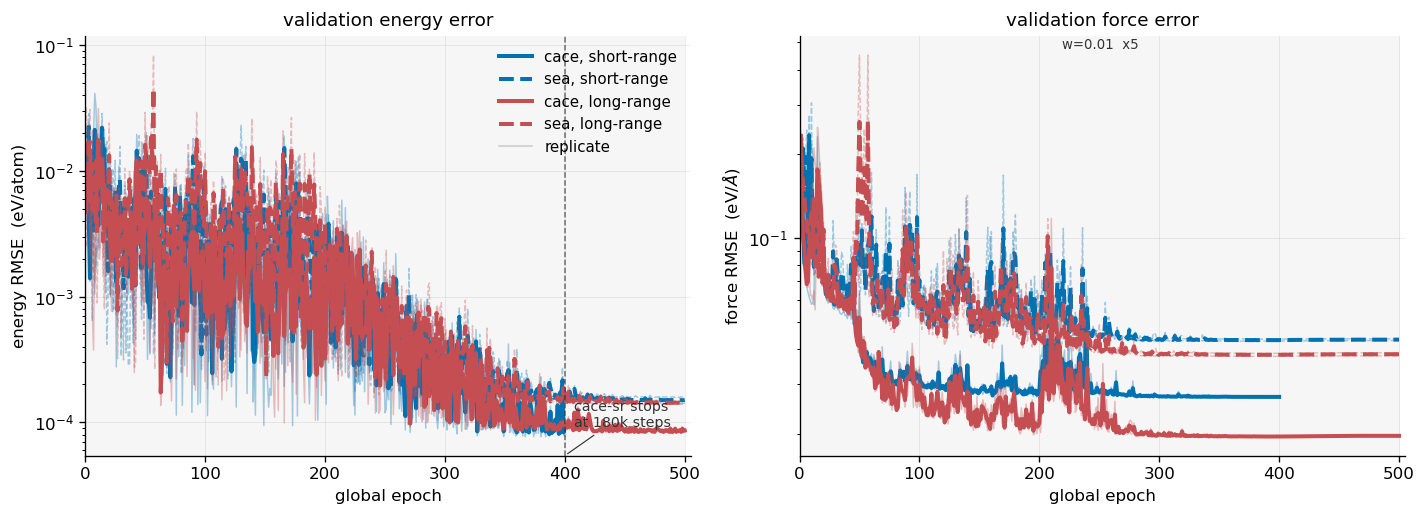

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), sharex=True)
panels = [("val_e_atom_rmse", "energy RMSE  (eV/atom)", "validation energy error"),
          ("val_f_rmse", "force RMSE  (eV/" + r"$\AA$" + ")", "validation force error")]

for ax, (value, ylabel, title) in zip(axes, panels):
    mark_schedule(ax, curves, labels=(ax is axes[1]))
    for family, topology in GROUPS:
        for arm_id in replicates(family, topology):
            sub = curves[curves.arm_id == arm_id].sort_values("global_epoch")
            ax.plot(sub.global_epoch, sub[value], lw=0.9, alpha=0.35, **arm_style(family, topology))
        x, y = pooled(curves, value, family, topology)
        ax.plot(x, y, lw=2.4, **arm_style(family, topology))
    ax.set_yscale("log")
    ax.set_xlabel("global epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(0, 505)

# cace-sr's shorter budget, marked once
axes[0].axvline(400, color=palette.INK, lw=0.9, ls="--", alpha=0.7)
axes[0].annotate("cace-sr stops\nat 180k steps", xy=(400, axes[0].get_ylim()[0]),
                 xytext=(408, axes[0].get_ylim()[0] * 1.6), fontsize=8.5, color=palette.INK,
                 ha="left", va="bottom",
                 arrowprops=dict(arrowstyle="-", lw=0.7, color=palette.INK))

axes[0].legend(handles=trace_legend(), loc="upper right", ncol=1)
fig.tight_layout()
plt.show()

The replicate traces are indistinguishable, so what the four arms do is a property of the arm and not of the seed.

Read the weight staircase against the curves.
The sharp drops at epochs 200, 300 and 400 are the energy weight being raised, not the model changing: the loss re-weights the same prediction.
The force RMSE is nearly flat across those jumps, which is the honest expectation - the weight acts on the energy term.

The two panels separate the two families and the two topologies at once:

* the red (long-range) traces sit below the blue (short-range) traces of the same line style in the **force** panel, in both families;
* in the **energy** panel the red and blue traces of a family are on top of each other.

## What the models actually score

The curves are the training trace; the numbers below are the models as frozen in `best_model.pth`, scored by `score_arms.py` over all 50 validation frames, one frame per batch, using the same loader for every arm.

The dots are the two replicates and the bar is their mean.
The small grey cross is the best value the training log ever printed, which is the campaign's own metric on the same 50 frames - it is plotted as a check on the scorer, not as a second result.

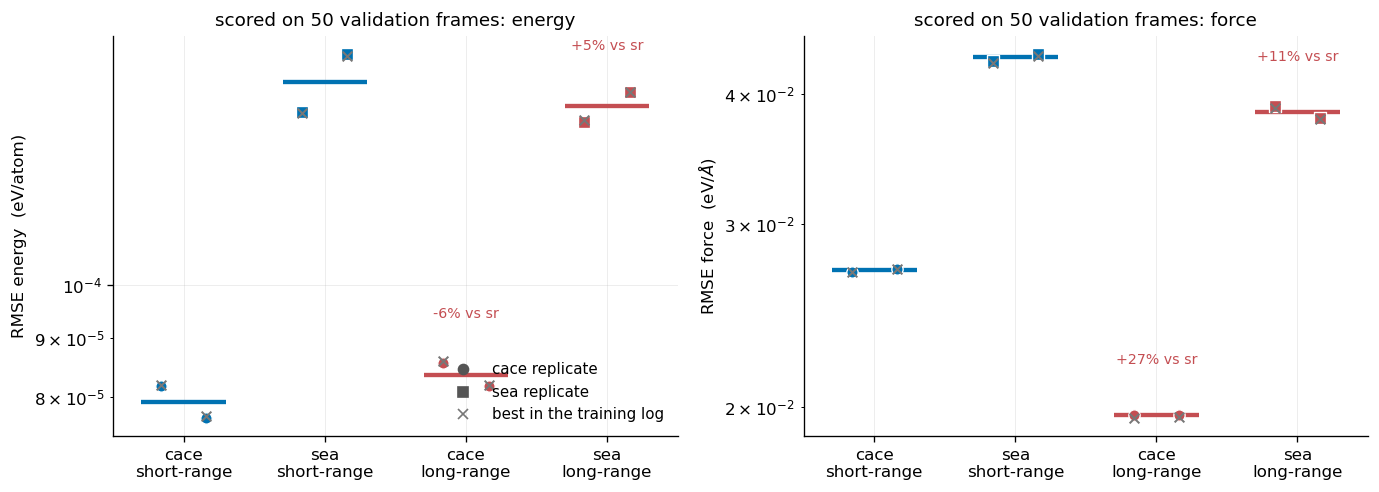

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
metric_labels = {"energy": "RMSE energy  (eV/atom)", "force": "RMSE force  (eV/" + r"$\AA$" + ")"}

for ax, key in zip(axes, ("energy", "force")):
    col = METRIC_COLUMNS[key]
    log_col = "val_e_atom_rmse" if key == "energy" else "val_f_rmse"
    for i, (family, topology) in enumerate(GROUPS):
        values, log_best = [], []
        for arm_id in replicates(family, topology):
            values.append(float(metrics.loc[metrics.arm_id == arm_id, col].iloc[0]))
            log_best.append(float(curves[curves.arm_id == arm_id][log_col].min()))
        offset = np.array([-0.16, 0.16])
        ax.scatter(i + offset, values, s=46, zorder=3, marker="o" if family == "cace" else "s",
                   facecolor=palette.TOPOLOGY_COLOR[topology], edgecolor="white", linewidth=0.8)
        ax.scatter(i + offset, log_best, s=34, zorder=3, marker="x", color="#777777", linewidth=1.2)
        ax.hlines(np.mean(values), i - 0.3, i + 0.3, lw=2.6,
                  color=palette.TOPOLOGY_COLOR[topology])
        gain = 100 * (1 - np.mean(values) / np.mean([
            float(metrics.loc[metrics.arm_id == f"{family}-sr_{r}", col].iloc[0]) for r in "AB"]))
        if topology == "lr":
            ax.annotate(f"{gain:+.0f}% vs sr", xy=(i, np.mean(values)), xytext=(i, np.mean(values) * 1.12),
                        ha="center", fontsize=8.5,
                        color=palette.TOPOLOGY_COLOR[topology])
    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels([GROUP_LABEL[g] for g in GROUPS])
    ax.set_ylabel(metric_labels[key])
    ax.set_yscale("log")
    ax.set_title(f"scored on 50 validation frames: {key}")
    ax.set_xlim(-0.5, len(GROUPS) - 0.5)

axes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color="#555555", label="cace replicate"),
    Line2D([], [], marker="s", ls="", color="#555555", label="sea replicate"),
    Line2D([], [], marker="x", ls="", color="#777777", label="best in the training log"),
], loc="lower right")
fig.tight_layout()
plt.show()

In [5]:
# the same numbers as a table, with the scorer-versus-log agreement made explicit
table = metrics[["arm_id", "n_params", "rmse_e_peratom", "rmse_f",
                 "energy_offset_peratom", "energy_scale_slope",
                 "energy_rmse_after_offset", "energy_rmse_after_scale"]].copy()
table["log_best_e"] = [float(curves[curves.arm_id == a].val_e_atom_rmse.min()) for a in table.arm_id]
table["log_best_f"] = [float(curves[curves.arm_id == a].val_f_rmse.min()) for a in table.arm_id]
table["scored_vs_log_f_pct"] = 100 * (table.rmse_f / table.log_best_f - 1)
table = table.set_index("arm_id")
table.style.format({c: "{:.3e}" for c in
                    ["rmse_e_peratom", "energy_offset_peratom", "energy_rmse_after_offset",
                     "energy_rmse_after_scale", "log_best_e"]}
                   | {"rmse_f": "{:.5f}", "log_best_f": "{:.5f}",
                      "energy_scale_slope": "{:.4f}", "scored_vs_log_f_pct": "{:+.2f}%",
                      "n_params": "{:,}"}).background_gradient(
    subset=["rmse_e_peratom", "rmse_f"], cmap="Oranges")

,n_params,rmse_e_peratom,rmse_f,energy_offset_peratom,energy_scale_slope,energy_rmse_after_offset,energy_rmse_after_scale,log_best_e,log_best_f,scored_vs_log_f_pct
arm_id,,,,,,,,,,
cace-sr_A,"24,572",8.172e-05,0.02698,1.891e-06,0.9969,8.169e-05,8.156e-05,8.200e-05,0.02698,+0.02%
cace-sr_B,"24,572",7.676e-05,0.02719,1.948e-06,0.9926,7.674e-05,7.593e-05,7.700e-05,0.02718,+0.01%
sea-sr_A,"79,178",1.413e-04,0.04306,1.159e-06,1.0066,1.413e-04,1.409e-04,1.410e-04,0.04284,+0.52%
sea-sr_B,"79,178",1.584e-04,0.04369,-6.984e-07,1.0145,1.584e-04,1.569e-04,1.580e-04,0.04356,+0.30%
cace-lr_A,"43,052",8.559e-05,0.01966,-5.541e-06,0.9981,8.541e-05,8.536e-05,8.600e-05,0.01954,+0.60%
cace-lr_B,"43,052",8.172e-05,0.01967,9.132e-07,0.9945,8.171e-05,8.129e-05,8.200e-05,0.01956,+0.59%
sea-lr_A,"124,314",1.385e-04,0.03894,-2.342e-06,1.0027,1.385e-04,1.385e-04,1.390e-04,0.03875,+0.49%
sea-lr_B,"124,314",1.470e-04,0.03797,-1.157e-06,1.0078,1.470e-04,1.466e-04,1.470e-04,0.03781,+0.42%


The scorer reproduces the campaign's own metric to within **0.6%** on every arm (`scored_vs_log_f_pct`), which is the difference between the checkpoint `best_model.pth` - chosen by validation loss, not by force error - and the single best epoch the log recorded.
That agreement is what makes the rest of this notebook trustworthy: the numbers being compared are the numbers the campaign itself was reading.

**Memory counts differ by a factor of three** (`n_params`), and they belong to the descriptor, not to the long-range channel: 24.6k for cace's short-range arm against 79.2k for sea's, and the long-range channel adds 18.5k in the cace family and 45.1k in the sea family.
`DescrptSeA` is simply the larger object.

**The energy error has no offset and no scale error to remove.**
Every arm's mean error is under `6e-6 eV/atom` and every fitted slope is between 0.993 and 1.015, so subtracting a constant or rescaling the axis would not move `rmse_e`.
What is left is shape, and the `after_offset` / `after_scale` columns barely differ from the raw RMSE because of it.

## The long-range channel, split into its parts

For the four long-range arms, `score_arms.py` reports the short-range and long-range pieces separately.
Both layouts emit each branch already multiplied by the coupling weight - `CombinePotential` scales it in place, and the sea arm uses that layout too - so the raw `ewald_potential` the branch computes is not the value the total receives.
The scorer divides the coupling back out, so `lr_e` and `lr_f` are the branch's own Ewald energy and force, and `sr_e` and `sr_f` are what is left of the total.
Each arm's total is then `E = E_sr + w * E_lr` with `w = 0.02`, read from the checkpoint rather than assumed (`potential_keys` in the cace arm, `long_range.weight` in the sea arm).
The split is exact: `sr + w*lr` reproduces the total to `2e-6 eV/A` on the force, and identically on the energy, where the short-range half is defined as a subtraction.

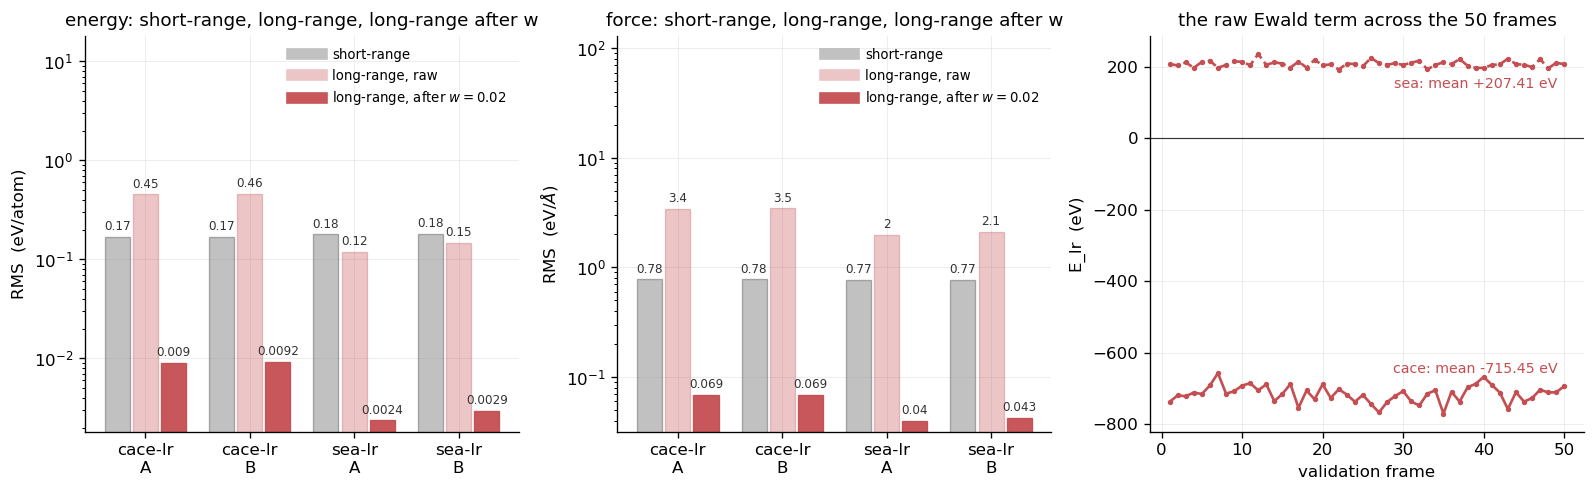

In [6]:
lr_arms = [a for a in ARM_IDS if a.split("_")[0].endswith("lr")]

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.2))

# (a) energy, (b) force: the short-range piece, the branch's own Ewald value,
# and that value after the w = 0.02 coupling. The third bar is what actually
# enters the total, and the collapse from the second to the third is the point
# of this figure.
for ax, key, ylabel in zip(axes[:2], ("energy", "force"),
                           ["RMS  (eV/atom)", "RMS  (eV/" + r"$\AA$" + ")"]):
    suffix = "_peratom" if key == "energy" else ""
    fields = [(f"sr_{key[0]}_rms{suffix}", "#999999", 0.60, "#777777"),
              (f"lr_{key[0]}_rms{suffix}", palette.TOPOLOGY_COLOR["lr"], 0.32, palette.TOPOLOGY_COLOR["lr"]),
              (f"lr_{key[0]}_rms{suffix}", palette.TOPOLOGY_COLOR["lr"], 0.95, palette.TOPOLOGY_COLOR["lr"])]
    for k, arm_id in enumerate(lr_arms):
        weight = float(metrics.loc[metrics.arm_id == arm_id, "weight"].iloc[0])
        for j, (field, color, alpha, edge) in enumerate(fields):
            value = float(metrics.loc[metrics.arm_id == arm_id, field].iloc[0])
            if j == 2:                                   # the coupled piece
                value *= weight
            x = k + (j - 1) * 0.27
            ax.bar(x, value, width=0.24, color=color, alpha=alpha, edgecolor=edge, linewidth=0.8)
            ax.annotate(f"{value:.2g}", xy=(x, value), xytext=(0, 4), textcoords="offset points",
                        ha="center", fontsize=7.2, color=palette.INK)
    ax.set_yscale("log")
    ax.set_xticks(range(len(lr_arms)))
    ax.set_xticklabels([arm_id.replace("_", "\n") for arm_id in lr_arms])
    ax.set_ylabel(ylabel)
    ax.set_title(f"{key}: short-range, long-range, long-range after w")
    ax.set_ylim(top=ax.get_ylim()[1] * 30)
    ax.legend(handles=[Line2D([], [], lw=7, color="#999999", alpha=0.60, label="short-range"),
                       Line2D([], [], lw=7, color=palette.TOPOLOGY_COLOR["lr"], alpha=0.32,
                              label="long-range, raw"),
                       Line2D([], [], lw=7, color=palette.TOPOLOGY_COLOR["lr"], alpha=0.95,
                              label="long-range, after $w=0.02$")],
              loc="upper right", fontsize=8)

# (c) the branch's own Ewald energy, frame by frame
ax = axes[2]
for family, topology in [("cace", "lr"), ("sea", "lr")]:
    values = np.mean([arrays(a, "lr_e") for a in replicates(family, topology)], axis=0)
    ax.plot(np.arange(1, len(values) + 1), values, lw=1.6,
            marker="o", ms=2.2, **arm_style(family, topology))
    ax.annotate(f"{family}: mean {values.mean():+.2f} eV", xy=(len(values), values[-1]),
                xytext=(-4, 8 if family == "cace" else -14), textcoords="offset points",
                ha="right", fontsize=8.5, color=palette.TOPOLOGY_COLOR["lr"])
ax.axhline(0, color=palette.INK, lw=0.7)
ax.set_xlabel("validation frame")
ax.set_ylabel("E_lr  (eV)")
ax.set_title("the raw Ewald term across the 50 frames")

fig.tight_layout()
plt.show()

In [7]:
decomposition = metrics.loc[metrics.arm_id.isin(lr_arms),
    ["arm_id", "weight", "sr_e_rms_peratom", "lr_e_rms_peratom", "lr_e_mean",
     "sr_f_rms", "lr_f_rms", "lr_f_over_total_f", "split_gap_e", "split_gap_f",
     "force_route_gap", "lr_force_route_gap"]].set_index("arm_id")
decomposition.style.format({c: "{:.4e}" for c in
    ["sr_e_rms_peratom", "lr_e_rms_peratom", "lr_e_mean", "sr_f_rms", "lr_f_rms",
     "split_gap_e", "split_gap_f", "force_route_gap", "lr_force_route_gap"]}
    | {"lr_f_over_total_f": "{:.3%}", "weight": "{:.2f}"})

,weight,sr_e_rms_peratom,lr_e_rms_peratom,lr_e_mean,sr_f_rms,lr_f_rms,lr_f_over_total_f,split_gap_e,split_gap_f,force_route_gap,lr_force_route_gap
arm_id,,,,,,,,,,,
cace-lr_A,0.02,1.6805e-01,4.5221e-01,-7.0779e+02,7.7938e-01,3.4368e+00,8.902%,0.0000e+00,1.7751e-06,1.7751e-06,3.9816e-05
cace-lr_B,0.02,1.6785e-01,4.6203e-01,-7.2312e+02,7.8052e-01,3.4562e+00,8.948%,0.0000e+00,1.9073e-06,1.9073e-06,4.0293e-05
sea-lr_A,0.02,1.7945e-01,1.1824e-01,1.8494e+02,7.6877e-01,1.9792e+00,5.125%,0.0000e+00,9.5367e-07,9.5367e-07,nan
sea-lr_B,0.02,1.8002e-01,1.4691e-01,2.2989e+02,7.6686e-01,2.1273e+00,5.505%,0.0000e+00,9.5367e-07,9.5367e-07,nan


Three things come out of the decomposition, and the first one changes the reading of everything that follows.

**The branch's own Ewald force is large, not a small additive piece.**
The raw long-range gradient `-dE_lr/dr` has an RMS of `3.44` and `3.46 eV/A` in the cace arms and `1.98` and `2.13 eV/A` in the sea arms - larger than the total force RMS of `0.772-0.774 eV/A` in every arm.
Only the coupling `w = 0.02` brings it down to a modest contribution: `0.0687` and `0.0691 eV/A` (cace), `0.0396` and `0.0426 eV/A` (sea), which is `8.90%`, `8.95%`, `5.12%` and `5.51%` of the total force magnitude.
The short-range piece keeps an RMS of `0.767-0.781 eV/A` in the four long-range arms, within about `1%` of the short-range arms' own total (`0.7725-0.7735`), so the added term does not change the force amplitude - it changes the shape.

**The two families learn different Ewald terms.**
The raw `E_lr` averages `-708` and `-723 eV` in the cace long-range arms and `+185` and `+230 eV` in the sea long-range arms, on top of short-range energies of `-263` and `-281 eV`.
The coupled contributions those add up to are only `-14.2`, `-14.5`, `+3.7` and `+4.6 eV`.
A sign difference in a quantity dominated by charge-charge repulsion means the net latent charge on the slab has the opposite sign in the two families.
Both are free to fit the data; the split simply says the learned charge distributions are not the same object.

**The split is exact and the two force routes agree.**
`split_gap_e` is exactly zero, and `split_gap_f` and `force_route_gap` are between `9e-7` and `2e-6 eV/A` - three orders of magnitude below the RMSEs being compared, which is float32 rounding.
The long-range force computed by the checkpoint's own `ewald_forces` module and by autograd on `E_lr` agree to `4e-5 eV/A`, the same precision at the scale of the raw Ewald force, so the decomposition is not an artifact of how it was extracted.

## The result

The question the campaign exists to answer is what the long-range channel is worth, and it has to be read separately for the two metrics.

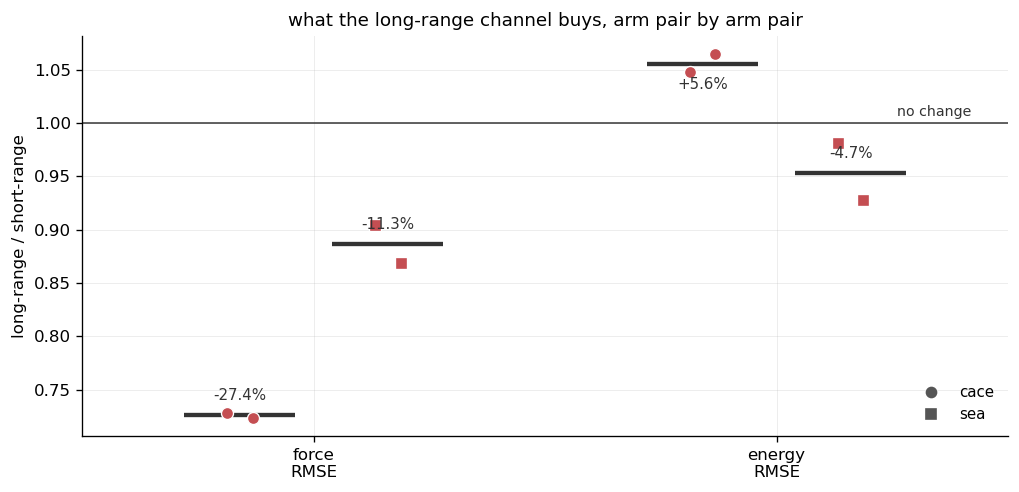

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
keys = ["force", "energy"]
offsets = {"cace": -0.16, "sea": 0.16}
for i, key in enumerate(keys):
    col = METRIC_COLUMNS[key]
    for family in FAMILIES:
        for j, rep in enumerate("AB"):
            sr = float(metrics.loc[metrics.arm_id == f"{family}-sr_{rep}", col].iloc[0])
            lr = float(metrics.loc[metrics.arm_id == f"{family}-lr_{rep}", col].iloc[0])
            ax.scatter(i + offsets[family] + (j - 0.5) * 0.055, lr / sr, s=52, zorder=3,
                       marker="o" if family == "cace" else "s",
                       facecolor=palette.TOPOLOGY_COLOR["lr"], edgecolor="white", linewidth=0.8)
        mean_sr = np.mean([float(metrics.loc[metrics.arm_id == f"{family}-sr_{rep}", col].iloc[0]) for rep in "AB"])
        mean_lr = np.mean([float(metrics.loc[metrics.arm_id == f"{family}-lr_{rep}", col].iloc[0]) for rep in "AB"])
        ax.hlines(mean_lr / mean_sr, i + offsets[family] - 0.12, i + offsets[family] + 0.12,
                  lw=2.6, color=palette.INK)
        ax.annotate(f"{100 * (mean_lr / mean_sr - 1):+.1f}%", xy=(i + offsets[family], mean_lr / mean_sr),
                    xytext=(0, 9 if mean_lr / mean_sr < 1 else -15), textcoords="offset points",
                    ha="center", fontsize=9, color=palette.INK)

ax.axhline(1.0, color=palette.INK, lw=0.9)
ax.text(1.42, 1.004, "no change", fontsize=8.5, color=palette.INK, va="bottom", ha="right")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels([f"{k}\nRMSE" for k in keys])
ax.set_ylabel("long-range / short-range")
ax.set_title("what the long-range channel buys, arm pair by arm pair")
ax.set_xlim(-0.5, len(keys) - 0.5)
ax.legend(handles=[Line2D([], [], marker="o", ls="", color="#555555", label="cace"),
                   Line2D([], [], marker="s", ls="", color="#555555", label="sea")],
          loc="lower right")
fig.tight_layout()
plt.show()

**The long-range channel reliably improves the force, in both families, by different amounts.**

| metric | cace | sea |
| --- | --- | --- |
| force RMSE, short-range | 0.02708 | 0.04337 |
| force RMSE, long-range | 0.01966 | 0.03845 |
| change | **-27.4%** | **-11.3%** |

**It does not improve the energy.**

| metric | cace | sea |
| --- | --- | --- |
| energy RMSE, short-range | 7.92e-5 | 1.50e-4 |
| energy RMSE, long-range | 8.37e-5 | 1.43e-4 |
| change | +5.6% (worse) | -4.7% (better) |


The two arms in a family are separate training runs, so the energy pair is two independent numbers, and they disagree in sign.
The honest reading is that the long-range channel has no effect on `rmse_e` that is larger than the run-to-run spread.

**The replicate spread is far smaller than either force effect.**
The two cace long-range replicates differ by `0.08%`, the two sea long-range replicates by `2.5%`, against effects of `27.4%` and `11.3%`.
The force win is a stable property of the arm, which is exactly what the earlier deepmd arms failed to show.

**The sea descriptor is worse than cace's at any topology.**
`1.60x` on short-range force, `1.96x` on long-range force, `1.89x` and `1.71x` on energy.
This is a statement about the descriptor and not about the training budget, because `sea-sr` was given 45,000 *more* steps than `cace-sr` and still lands 1.60x worse.

## What the force win actually is

The force improvement in the long-range arms is large and stable, and - read against the decomposition above - it is **not a small correction added to an unchanged short-range network**.
The Ewald force is large, and the short-range network, retrained inside the same objective, very nearly cancels it; what survives is the small net improvement the headline table reports.

The arithmetic rules the direct reading out.
Write the change from the short-range arm to the long-range arm as the sum of two pieces: the Ewald force the long-range arm adds, and the change in the short-range network it was trained alongside.
In the cace family the two pieces have RMS `0.0688` and `0.0665 eV/A` and are nearly anti-parallel (`cos = -0.96`); in the sea family `0.0406` and `0.0376 eV/A` at `cos = -0.83`.
Each piece is `1.6x` to `3.6x` larger than the `0.019` and `0.023 eV/A` shift they leave behind, so the Ewald term is not small next to the net improvement - most of it is cancelled, not absent.
The reading that follows is not that the short-range network moved on its own, but that adding the Ewald term moved it, by very nearly the amount needed to oppose the new term.

The two tables below make that concrete.
The first splits each arm's force error into the part shared by its two replicates - a reproducible, systematic error - and the seed-to-seed part.

In [9]:
def force_error(family, topology, rep):
    arm_id = f"{family}-{topology}_{rep}"
    return arrays(arm_id, "pred_f") - arrays(arm_id, "ref_f")


def rms(x):
    return float(np.sqrt(np.mean(np.asarray(x) ** 2)))


stability = []
for family in FAMILIES:
    for topology in TOPOLOGIES:
        eA, eB = force_error(family, topology, "A"), force_error(family, topology, "B")
        systematic, seed = (eA + eB) / 2, (eA - eB) / 2
        mean_square = 0.5 * (rms(eA) ** 2 + rms(eB) ** 2)
        stability.append({
            "family": family, "topology": topology,
            "rmse_f": np.sqrt(mean_square),
            "systematic": rms(systematic),
            "seed_random": rms(seed),
            "systematic_share": rms(systematic) ** 2 / mean_square,
            "lr_vs_sr": np.nan,
        })
stability = pd.DataFrame(stability).set_index(["family", "topology"])
for family in FAMILIES:
    sr = stability.loc[(family, "sr"), "systematic"]
    stability.loc[(family, "lr"), "lr_vs_sr"] = stability.loc[(family, "lr"), "systematic"] / sr - 1.0
stability.style.format({"rmse_f": "{:.5f}", "systematic": "{:.5f}", "seed_random": "{:.5f}",
                        "systematic_share": "{:.1%}",
                        "lr_vs_sr": lambda v: "" if pd.isna(v) else f"{v:+.1%}"})

**Nearly all of the error is systematic, and the long-range channel cuts it.**
Between `94%` and `98%` of each arm's squared force error is shared between its two replicates (`systematic_share`), so an arm's force accuracy is a reproducible property of its recipe and not a lucky draw - which is what licenses comparing the arms at all.
The systematic error falls by `27.7%` in the cace family and `12.4%` in the sea family - the same effect the headline table reports as `27.4%` and `11.3%`, read on the shared component instead of the overall RMSE - both far beyond the seed-to-seed scatter (`seed_random`, a few thousandths of an eV/A).

The second table asks where that change lives.

In [10]:
shifts = []
for family in FAMILIES:
    srA, srB = f"{family}-sr_A", f"{family}-sr_B"
    lrA, lrB = f"{family}-lr_A", f"{family}-lr_B"
    weight = float(metrics.loc[metrics.arm_id == lrA, "weight"].iloc[0])
    # The change from the short-range arm to the long-range arm, split into the
    # two things that make it up: the short-range network's own change, and the
    # Ewald force the long-range arm adds. They sum to the shift by construction.
    dA = arrays(lrA, "pred_f") - arrays(srA, "pred_f")
    dB = arrays(lrB, "pred_f") - arrays(srB, "pred_f")
    shift = 0.5 * (dA + dB)
    network = 0.5 * ((arrays(lrA, "sr_f") - arrays(srA, "pred_f"))
                     + (arrays(lrB, "sr_f") - arrays(srB, "pred_f")))
    ewald = weight * np.mean([arrays(lrA, "lr_f"), arrays(lrB, "lr_f")], axis=0)
    shifts.append({
        "family": family,
        "sr_to_lr_shift": rms(shift),
        "sr_network_change": rms(network),
        "ewald_force": rms(ewald),
        "cos_network_vs_ewald": float(np.sum(network * ewald)
                                      / (np.linalg.norm(network) * np.linalg.norm(ewald))),
        "cos_shift_vs_ewald": float(np.sum(shift * ewald)
                                    / (np.linalg.norm(shift) * np.linalg.norm(ewald))),
        "shift_direction_cos": float(np.sum(dA * dB) / (np.linalg.norm(dA) * np.linalg.norm(dB))),
        "ewald_over_shift": rms(ewald) / rms(shift),
    })
shifts = pd.DataFrame(shifts).set_index("family")
shifts.style.format({"sr_to_lr_shift": "{:.5f}", "sr_network_change": "{:.5f}",
                     "ewald_force": "{:.5f}", "cos_network_vs_ewald": "{:+.3f}",
                     "cos_shift_vs_ewald": "{:+.3f}", "shift_direction_cos": "{:+.3f}",
                     "ewald_over_shift": "{:.2f}"})

,sr_to_lr_shift,sr_network_change,ewald_force,cos_network_vs_ewald,cos_shift_vs_ewald,shift_direction_cos,ewald_over_shift
family,,,,,,,
cace,0.01890,0.06649,0.06876,-0.961,+0.255,+0.843,3.64
sea,0.02313,0.03762,0.04060,-0.828,+0.409,+0.528,1.76


**The change is a cancellation, and the amplitude carries no information.**
Moving from the short-range arm to the long-range arm changes the prediction by `0.019 eV/A` (cace) and `0.023 eV/A` (sea), consistently across replicates (`shift_direction_cos` `+0.84` cace, `+0.53` sea).
The table above shows that this net change is the residual of two much larger, nearly opposing pieces - the added Ewald force and the shift in the short-range network - so its small size is a cancellation, not an absence.
The amplitude carries nothing either way: every arm, short-range and long-range alike, has a total force RMS of `0.772-0.774 eV/A`, and the long-range arms' short-range piece holds at `0.767-0.781 eV/A`, within about `1%` of the short-range arms' own total.
The amplitude is the same and the *shape* is better.

**What this does not settle.** Whether the cancellation is the intended physics or the network absorbing a term it cannot put to use cannot be told apart from these runs alone - the `sr` and `lr` arms also differ in schedule length, and separating the two would need the same architecture trained with and without the Ewald module under an identical budget. What the numbers do establish is that the win is real, systematic, and accompanied by a large, opposing change in the short-range network.

The diagnostic figure below rules out the other candidate explanation - that the long-range arms are simply better calibrated.
They are not: no arm has an offset or a scale error to remove, so the improvement has to be in the shape of the prediction.

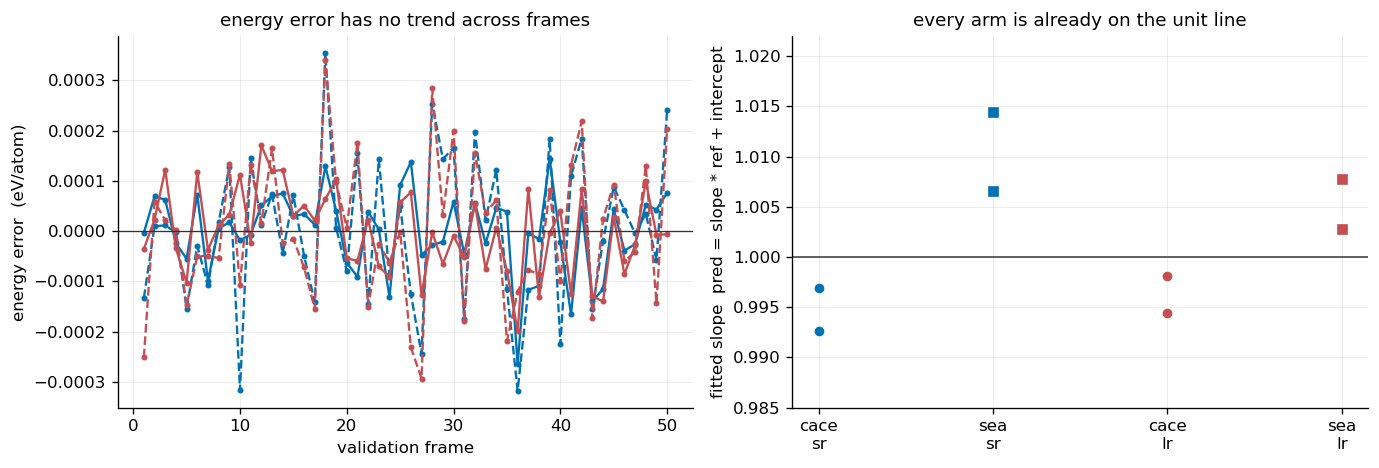

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0))

ax = axes[0]
for family, topology in GROUPS:
    error = np.mean([arrays(a, "energy_error") for a in replicates(family, topology)], axis=0)
    ax.plot(np.arange(1, len(error) + 1), error, lw=1.4, marker="o", ms=2.6,
            **arm_style(family, topology))
ax.axhline(0, color=palette.INK, lw=0.8)
ax.set_xlabel("validation frame")
ax.set_ylabel("energy error  (eV/atom)")
ax.set_title("energy error has no trend across frames")

ax = axes[1]
slopes = [(f"{f}-{t}", float(metrics.loc[metrics.arm_id == f"{f}-{t}_A", "energy_scale_slope"].iloc[0]),
           float(metrics.loc[metrics.arm_id == f"{f}-{t}_B", "energy_scale_slope"].iloc[0]))
          for f, t in GROUPS]
for i, (name, a, b) in enumerate(slopes):
    family, topology = name.split("-")
    ax.scatter([i] * 2, [a, b], s=44, marker="o" if family == "cace" else "s",
               facecolor=palette.TOPOLOGY_COLOR[topology], edgecolor="white", linewidth=0.8, zorder=3)
ax.axhline(1.0, color=palette.INK, lw=0.9)
ax.set_xticks(range(len(slopes)))
ax.set_xticklabels([s[0].replace("-", "\n") for s in slopes])
ax.set_ylim(0.985, 1.022)
ax.set_ylabel("fitted slope  pred = slope * ref + intercept")
ax.set_title("every arm is already on the unit line")

fig.tight_layout()
plt.show()

## What this says about the two campaigns

**The sea route works, and it is the cleaner experiment.**
Substituting `DescrptSeA` into cace's training loop gives a model that trains on cace's schedule with cace's metric, and the long-range channel then buys a force improvement of `11.3%` that is consistent across both replicates.
Nothing about that result depends on the deepmd training stack, which is what made the earlier deepmd arms such an unreliable witness.

**But the descriptor, not the long-range channel, is the big lever here.**
`DescrptSeA` costs a factor of `1.60` in force RMSE against cace's own descriptor at short range, while the long-range channel is worth a factor of `1.13` going the other way in the sea family.
A better short-range descriptor moves the number much further than the long-range correction does.

**The energy is not a good discriminator on this system.**
All eight arms land between `7.7e-5` and `1.6e-4` eV/atom, and the long-range channel does not separate them.
Any conclusion drawn from `rmse_e` alone on this benchmark would be reading noise, which is a reason to keep the force metric as the headline.

## Caveats, kept with the results

* **The step budgets differ.** `sea-sr` 225,000 steps against `cace-sr`'s 180,000, because the sea runner was given the long-range schedule for both arms and cace's published short-range script stops at its 7th block.
  This works against sea in the descriptor comparison, so it does not weaken the conclusion - but the two `sr` arms are not a matched pair, and neither are the `sr`-to-`lr` gains across families.
* **The energy comparison is two samples per family.** With a sign disagreement between the cace and sea energy deltas, no effect on `rmse_e` is established here in either direction.
* **One benchmark.** A single 500-frame water-interface slab, 450/50 split, one seed for the split. These are diagnostic comparisons on a fixed dataset, not accuracy claims about the models in general.
* **`best_model.pth` is selected on validation loss**, so the scored numbers are the force error at the epoch the loss preferred. They still land within `0.6%` of the best force error the logs ever recorded, so the selection is not distorting the comparison.